In [39]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize \
    python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import sys
import os

# Add project root (210226) to Python path
sys.path.append(os.path.abspath(".."))

from utils.prepare_data import prepare_data

In [41]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [42]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

Load env

In [43]:
from dotenv import load_dotenv
load_dotenv()

True

In [44]:
ibmq_token = os.getenv('IBMQ_TOKEN')
# from qiskit_ibm_runtime import QiskitRuntimeService
 
# QiskitRuntimeService.save_account(
#   token='ibmq_token',
#   overwrite=True
# )

In [45]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [46]:
dataset_path = '../dataset/Dataset_TehHijau.csv'
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    # 'full', 
    'linear', 
    # 'circular', 
    # 'pauli_x', 
    # 'pauli_y', 
    # 'pauli_z'
]
kernel_types = [
    'linear', 
    'poly', 
    'rbf', 
    'sigmoid'
]

In [47]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

# from ucimlrepo import fetch_ucirepo 
  
# # fetch dataset 
# data = fetch_ucirepo(id=53) 
  
# # data (as pandas dataframes) 
# X = data.data.features 
# y = data.data.targets 
  
# # metadata 
# print(data.metadata) 
  
# # variable information 
# print(data.variables) 

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,46.5,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.4

In [48]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,1.040900e+04,1.040900e+04,1.040900e+04,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.0,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000
mean,89.414833,47.600730,47.936209,98.291575,89.182246,51.548756,533.670093,213.738592,531.124604,330.500336,48.387732,39.656701,2.935143,34.888942,3.035383,3.135306,3.071880,89.401187,88.072610,90.838121,0.983066,0.031130,-0.497871,797.282995,51.381383,46.428283,86.377366,12.767992,0.047886,-0.767730,461.091603,48.923492,46.665674,56.401095,3.417439,0.042129,-0.742829,435.501633,98.319587,97.190220,99.975002,0.977440,0.153864,-0.336209,872.003728,89.167083,87.839082,90.566625,0.975194,0.054069,-0.778237,790.103132,52.047207,50.200692,56.931309,2.411880,0.011063,-0.779548,460.377366,533.585382,530.475646,535.648189,1.716062,-0.230519,-0.613955,4754.938419,215.542657,212.039427,231.564223,6.549817,-0.059306,-0.657508,1919.990364,531.039823,529.310693,532.089442,1.000540,-0.031123,-0.890127,4742.842444,330.447166,328.831396,331.640503,0.980595,0.022313,-0.777011,2953.280046,4.077809e+03,48.175252,4.034278e+04,1.274229e+04,-2.069636e-02,-0.

Text(0.5, 1.0, 'Histogram for the Kategori')

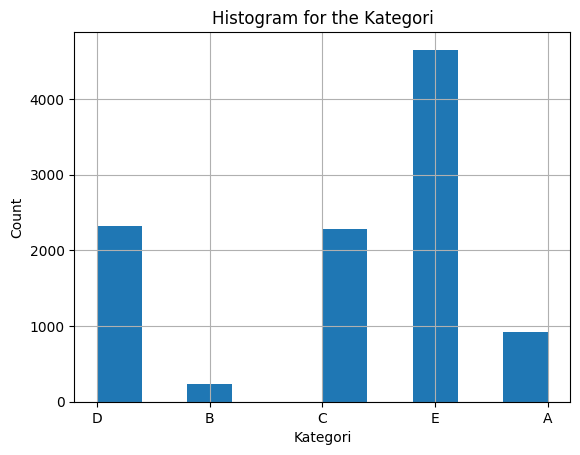

In [49]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
# y.value_counts().plot(kind='bar')
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

## Preprocess

In [50]:
# from utils.preprocess import preprocess
# data = preprocess(data)

In [51]:
distinct_classes_df = data.drop_duplicates(subset=['Kategori'])
distinct_classes_df

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.000000,-2.000000,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.000000,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-3.656751e-01,-0.705532,417.95,38.81,38.7,38.9,0.087560,-0.188430,-1.526150,349.30,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
493,89.0,42.0,43.0,109.0,91.0,45.0,544.0,259.0,539.0,356.0,49.9,40.5,TR610,TR610_1,3.0,33,3.0,3.5,2.9,B,Baik,88.7,88.0,90,0.674949,0.365675,-0.705532,797.5,42.6,42,43,0.516398,-0.408248,-1.833333,383.5,42.4,41,43,0.699206,-0.657843,-0.628099,381.5,109.5,109,110.0,0.527046,0.000000,-2.000000,986.0,92.1,91,93,0.737865,-0.139942,-0.960433,829.5,45.4,44,47,0.843274,0.328125,-0.335937,409.0,544.7,544,545,0.483046,-0.872872,-1.238095,4902.5,260.0,259.0,261,0.816497,0.000000,-1.333333,2340.5,539.6,538,540,0.699206,-1.397916,0.611570,4856.5,356.4,355,357,0.843274,-0.843750,-0.921875,3207.5,49.80,49.7,49.9,0.066667,1.685131e-13,-0.500000,448.20,40.43,40.4,40.5,0.048305,0.872872,-1.238095,363.85,3.0,3.0,3.0,0.000000e+00,27.0,33,33,33,0,297,3.0,3.0,3.0,0.000000e+00,27.0,3.5,3.5,3.5,0.000000e+00,31.5,2.9,2.9,2.9,4.681111e-16,26.1
622,83.0,39.0,41.0,87.0,84.0,44.0,541.0,206.0,536.0,330.0,49.0,39.8,TR619,TR619_1,2.6,32,2.7,2.8,2.6,C,Cacat Mutu,84.2,83.0,85,0.632456,-0.111111,-0.444444,758.5,40.3,39,42,0.823273,0.680065,0.154260,363.5,40.4,39,42,0.966092,-0.093522,-0.897959,362.5,87.2,87,88.0,0.421637,1.500000,0.250000,785.0,84.9,84,86,0.875595,0.188430,-1.526150,764.5,43.0,42,44,0.942809,0.000000,-1.750000,386.0,540.6,539,541,0.699206,-1.397916,0.611570,4865.5,206.5,206.0,207,0.527046,0.000000,-2.000000,1858.5,535.7,535,537,0.823273,0.579314,-1.135716,4821.5,330.9,330,332,0.737865,0.139942,-0.960433,2978.5,48.90,48.8,49.0,0.081650,9.331327e-17,-1.333333,440.10,39.71,39.7,39.8,0.031623,2.666667,5.111111,357.35,2.6,2.6,2.6,4.681111e-16,23.4,32,32,32,0,288,2.7,2.7,2.7,4.681111e-16,24.3,2.8,2.8,2.8,4.681111e-16,25.2,2.6,2.6,2.6,4.681111e-16,23.4
807,84.0,39.0,40.0,78.0,84.0,41.0,542.0,207.0,538.0,337.0,

In [52]:
X = data[feature_cols]
y = data[target_cols]


cat_features = [
    i for i, col in enumerate(X.columns)
    if X[col].dtype == 'object'
]

print(X.shape, y.shape)

(10409, 12) (10409,)


## PCA

In [53]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

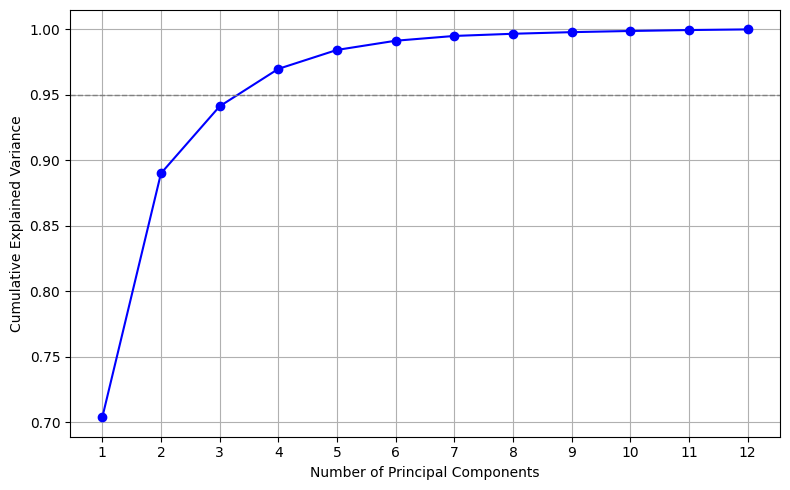

Optimal number of components to retain 95% variance: 4


In [54]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.95)

In [55]:
# pca_final = PCA(n_components=n_optimal)
# X = pca_final.fit_transform(X)
# print(X.shape)

## Pipeline Config

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from model.quantum.qsvc import QSVCWrapper
from model.quantum.qesvc import QESVC
from model.libsvm.libsvm_model import LibSVMModel
from model.quantum.qxgb import QXGB

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# CONFIG
random_state = 42

# QUANTUM CONFIG
use_hardware = False

models = {
    # 'SVC_linear': SVC(kernel='linear', random_state=random_state, probability=True),
    # 'SVC_poly': SVC(kernel='poly', random_state=random_state, probability=True),
    # 'SVC_rbf': SVC(kernel='rbf', random_state=random_state, probability=True),
    # 'SVC_sigmoid': SVC(kernel='sigmoid', random_state=random_state, probability=True),

    'XGB_gbtreee': XGBClassifier(
      booster='gbtree',
      objective='multi:softprob', 
      random_state=random_state,
    ),
    # 'XGB_dart': XGBClassifier(
    #   booster='dart',
    #   objective='multi:softprob', 
    #   random_state=random_state,
    # ),


    # 'CatBoost': CatBoostClassifier(
    #   loss_function="MultiClassOneVsAll",
    #   iterations=1000,
    #   learning_rate=0.1,
    #   depth=6,
    #   eval_metric="Accuracy",
    #   verbose=0,
    #   random_seed=random_state,
    # ),

    # 'LibSVM_linear': LibSVMModel(kernel='linear'),
    # 'LibSVM_poly': LibSVMModel(kernel='poly', gamma=0.5, degree=3),
    # 'LibSVM_rbf': LibSVMModel(kernel='rbf', gamma=0.5),
    # 'LibSVM_sigmoid': LibSVMModel(kernel='sigmoid', gamma=0.5),

    # 'QSVC_full': QSVCWrapper(
    #   kernel='full', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QSVC_linear': QSVCWrapper(
    #   kernel='linear', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QSVC_circular': QSVCWrapper(
    #   kernel='circular', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QSVC_pauli_x': QSVCWrapper(
    #   kernel='pauli_x', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QSVC_pauli_y': QSVCWrapper(
    #   kernel='pauli_y', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QSVC_pauli_z': QSVCWrapper(
    #   kernel='pauli_z', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),

    # 'QESVC_full': QESVC(
    #   kernel='full', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QESVC_linear': QESVC(
    #   kernel='linear', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QESVC_circular': QESVC(
    #   kernel='circular', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QESVC_pauli_x': QESVC(
    #   kernel='pauli_x', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QESVC_pauli_y': QESVC(
    #   kernel='pauli_y', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),
    # 'QESVC_pauli_z': QESVC(
    #   kernel='pauli_z', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    #   C=1.0,
    #   lambda_=1.0
    # ),

    # Hybrid Quantum-XGBoost
    # 'QXGB_full': QXGB(
    #   kernel='full', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    # ),
    # 'QXGB_linear': QXGB(
    #   kernel='linear', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    # ),
    # 'QXGB_circular': QXGB(
    #   kernel='circular', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    # ),
    'QXGB_pauli_x': QXGB(
      kernel='pauli_x', 
      use_hardware=use_hardware, 
      n_features=n_optimal, 
      random_state=random_state, 
      n_qubits=n_optimal,
    ),
    # 'QXGB_pauli_y': QXGB(
    #   kernel='pauli_y', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    # ),
    # 'QXGB_pauli_z': QXGB(
    #   kernel='pauli_z', 
    #   use_hardware=use_hardware, 
    #   n_features=n_optimal, 
    #   random_state=random_state, 
    #   n_qubits=n_optimal,
    # ),
}

def build_pipeline(name, model):
  return Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_optimal)),
    ('clf', model)
  ])

pipelines = {
  name: build_pipeline(name, model) for name, model in models.items()
}

In [57]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

state = 42
n_splits = 5

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=state, stratify=y)
all_results = {name: {
    'accuracy': [], 
    'precision': [], 
    'recall': [], 
    'f1': [], 
    'confusion_matrix': [],
    'y_true': [],
    'y_prob': [],
} 
        for name in pipelines}

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
    # print(f"\rFold: {fold}/{n_splits}     ", end="")
    print(f"Fold: {fold}/{n_splits}")

    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y_encoded[train_index], y_encoded[test_index]

    for name, pipe in pipelines.items():
        pipe.fit(X_train_fold, y_train_fold)
        y_pred = pipe.predict(X_test_fold)

        if hasattr(pipe['clf'], 'predict_proba'):
            y_prob = pipe.predict_proba(X_test_fold)
        else:
            y_prob = None
        
        all_results[name]['y_true'].append(y_test_fold)
        all_results[name]['y_prob'].append(y_prob)
        
        report = classification_report(y_test_fold, y_pred, output_dict=True)
        all_results[name]['accuracy'].append(report['accuracy'])
        all_results[name]['precision'].append(report['weighted avg']['precision'])
        all_results[name]['recall'].append(report['weighted avg']['recall'])
        all_results[name]['f1'].append(report['weighted avg']['f1-score'])
        all_results[name]['confusion_matrix'].append(confusion_matrix(y_test_fold, y_pred))

        
        acc = report['accuracy']
        prec = report['weighted avg']['precision']
        recall = report['weighted avg']['recall']
        f1 = report['weighted avg']['f1-score']

        print(f"{name:15s}  |   acc={acc:.3f} | prec={prec:.3f} | recall:{recall:.3f} | f1:{f1:.3f}")
    # data_obj = {
    #     'X_train': X_train_fold,
    #     'y_train': y_train_fold,
    #     'X_test': X_test_fold,
    #     'y_test': y_test_fold,
    #     'cat_features': cat_features
    #     # 'classes': sorted(y.unique())
    #     # 'X_test': X_test,  # We pass the test set through just so it gets transformed
    #     # 'y_test': y_test
    # }

    # preprocessed_data = preprocess(data_raw)
    # last_data = data_obj

    # model_outputs = {
    #     "SVC": evaluate_svc(data_obj, kernel_types, use_hpo=True, n_splits=n_splits, fold=fold),
    #     # "XGBoost": evaluate_xgboost(data_obj, kernel_types),
    #     # "CatBoost": evaluate_catboost(data_obj, kernel_types),
    #     # "Quantum": evaluate_quantum(data_obj, quantum_kernel_types, use_hardware=True),
    #     # "LibSVM": evaluate_libsvm(data_obj, kernel_types)
    # }

    # for model_name, results in model_outputs.items():
    #     for r in results:
    #         # print(f"Model: {model_name} - Kernel: {r['kernel']}")
    #         # print(f"Accuracy: {r['accuracy']:.4f}, Precision(w): {r['weighted_precision']:.4f}, Recall(w): {r['weighted_recall']:.4f}, F1-Score(w): {r['weighted_f1-score']:.4f}")
    #         r_copy = r.copy()
    #         r_copy["model"] = model_name
    #         r_copy["random_state"] = state
    #         all_results.append(r_copy)

    # print("=" * 80)

Fold: 1/5
XGB_gbtreee      |   acc=0.976 | prec=0.976 | recall:0.976 | f1:0.976
QSVC_pauli_x     |   acc=0.885 | prec=0.891 | recall:0.885 | f1:0.885
QXGB_pauli_x     |   acc=0.976 | prec=0.977 | recall:0.976 | f1:0.977
Fold: 2/5
XGB_gbtreee      |   acc=0.977 | prec=0.977 | recall:0.977 | f1:0.977
QSVC_pauli_x     |   acc=0.902 | prec=0.904 | recall:0.902 | f1:0.902
QXGB_pauli_x     |   acc=0.981 | prec=0.981 | recall:0.981 | f1:0.981
Fold: 3/5
XGB_gbtreee      |   acc=0.972 | prec=0.972 | recall:0.972 | f1:0.972
QSVC_pauli_x     |   acc=0.896 | prec=0.900 | recall:0.896 | f1:0.895
QXGB_pauli_x     |   acc=0.971 | prec=0.971 | recall:0.971 | f1:0.971
Fold: 4/5
XGB_gbtreee      |   acc=0.975 | prec=0.974 | recall:0.975 | f1:0.974
QSVC_pauli_x     |   acc=0.907 | prec=0.911 | recall:0.907 | f1:0.908
QXGB_pauli_x     |   acc=0.975 | prec=0.975 | recall:0.975 | f1:0.974
Fold: 5/5
XGB_gbtreee      |   acc=0.966 | prec=0.967 | recall:0.966 | f1:0.966
QSVC_pauli_x     |   acc=0.884 | prec=0.

In [58]:
# Aggregate the results

from utils.aggregate_result import aggregate_results
final_aggregated_results_df, confusion_matrices = aggregate_results(all_results)

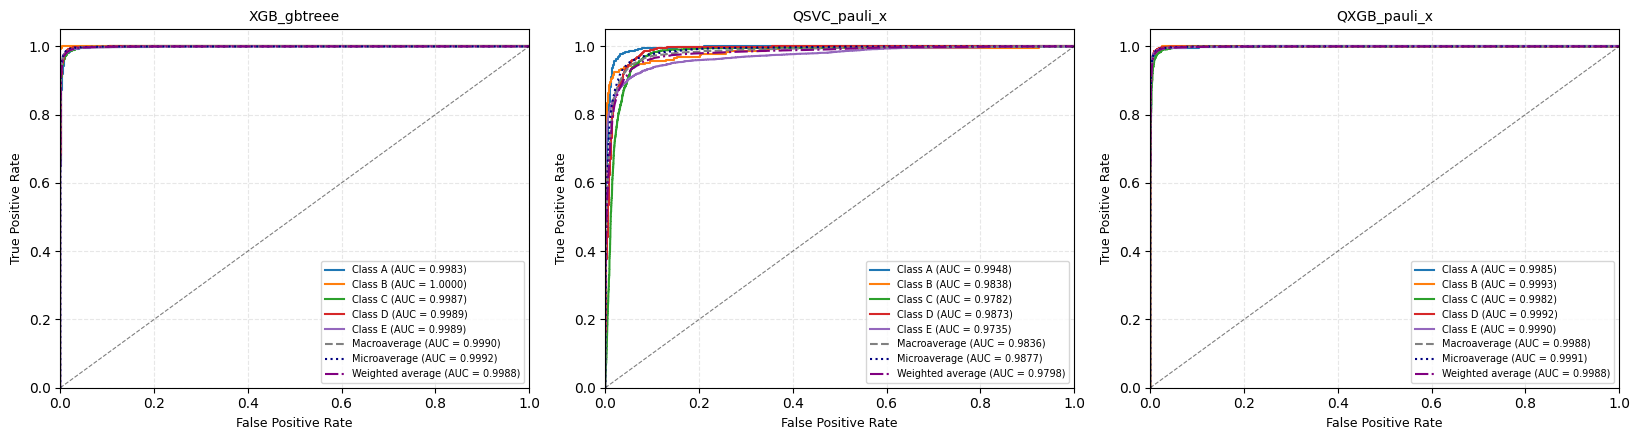

In [59]:
from utils.plots import plot_roc_curve
plot_roc_curve(all_results, list(all_results.keys()), le)

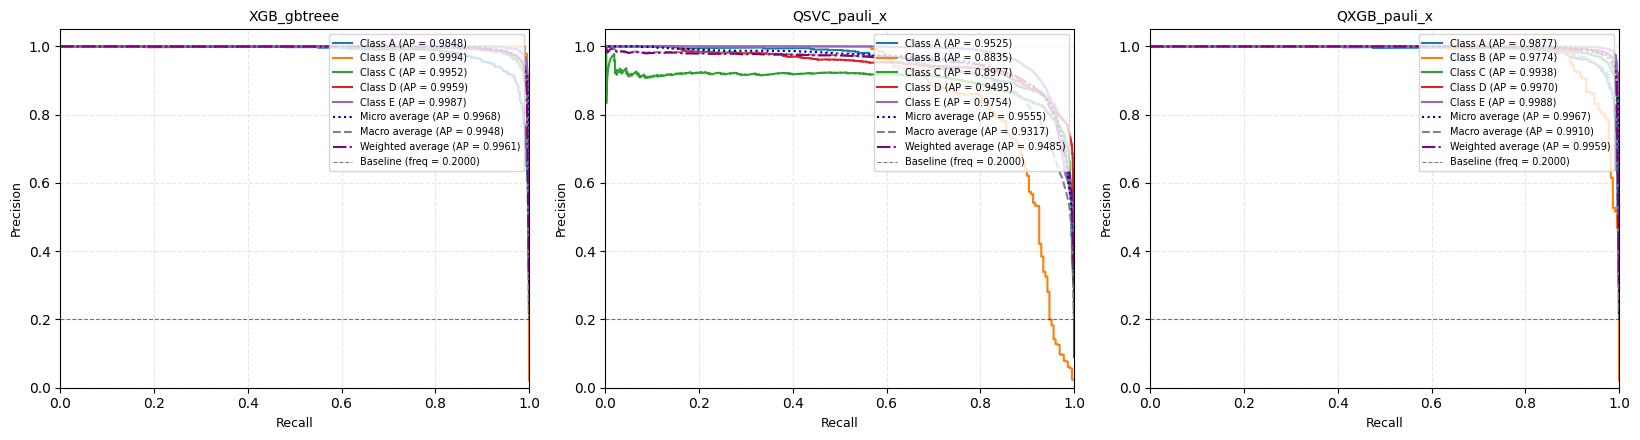

In [60]:
from utils.plots import plot_prauc
plot_prauc(all_results, list(all_results.keys()), le)

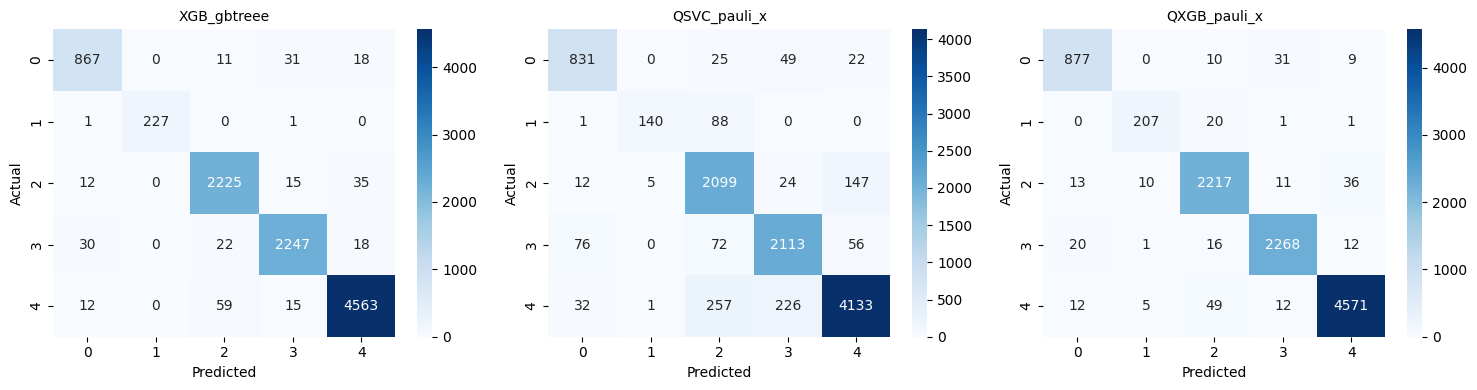

In [61]:
from utils.plots import plot_conf_matrix
plot_conf_matrix(confusion_matrices)

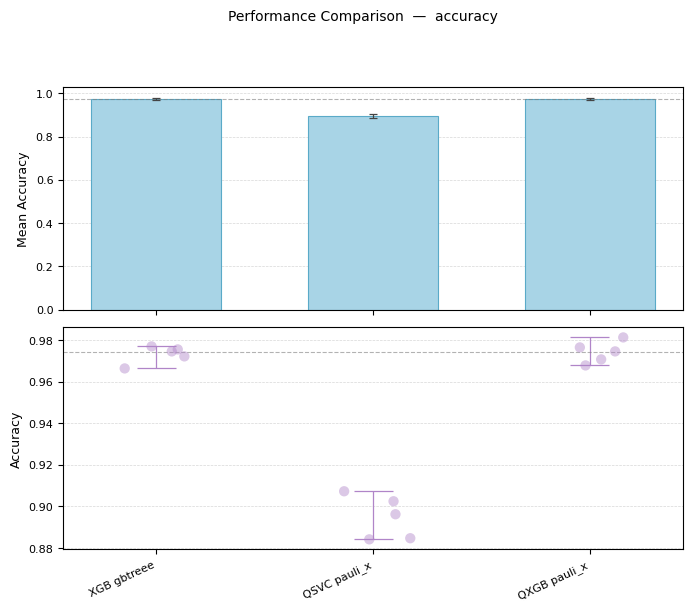

In [62]:
from utils.plots import plot_performance_comparison

plot_performance_comparison(final_aggregated_results_df, all_results, metric='accuracy')

In [63]:

from utils.report import report

# 2. Print metrric table
report(final_aggregated_results_df)

MODEL COMPARISON REPORT
                   accuracy      precision         recall             f1
model_kernel                                                            
XGB gbtreee   0.973 ± 0.004  0.973 ± 0.004  0.973 ± 0.004  0.973 ± 0.004
QSVC pauli_x  0.895 ± 0.009  0.899 ± 0.008  0.895 ± 0.009  0.895 ± 0.009
QXGB pauli_x  0.974 ± 0.005  0.974 ± 0.005  0.974 ± 0.005  0.974 ± 0.005

HIGHLIGHTS

ACCURACY
  Best  : QXGB pauli_x     0.974
  Worst : QSVC pauli_x     0.895

PRECISION
  Best  : QXGB pauli_x     0.974
  Worst : QSVC pauli_x     0.899

RECALL
  Best  : QXGB pauli_x     0.974
  Worst : QSVC pauli_x     0.895

F1
  Best  : QXGB pauli_x     0.974
  Worst : QSVC pauli_x     0.895

STABILITY (lower std = more stable)

  Most stable  : XGB gbtreee      std=0.004
  Least stable : QSVC pauli_x     std=0.009
